# Local Spatial Clustering & Hot-Spot Overlap Analysis (LISA)

**Author:** Gustavo Fuentes (`Audileleach`) · Phase 3 · TEAM_PLAN §4.6  
**Study Area:** Mexico City City-Core Urban AGEBs (2,348 units; 2,297 for rate metrics)  
**Methodology:** Local Indicators of Spatial Association (LISA / Anselin 1995) using PySAL `esda`  

This notebook analyzes local spatial clustering across Mexico City's urban fabric, focusing on two central questions:
1. **Where do significant economic and public-safety clusters concentrate?** (High-High, Low-Low, High-Low, Low-High)
2. **Do business density hot spots coincide with crime rate hot spots?** (Empirical overlap analysis)
3. **How robust are these spatial clusters to neighbourhood specifications?** (Queen contiguity vs. KNN-6)

> **Caution on Interpretation:** Cluster labels denote exploratory spatial association, not individual victimisation probabilities or direct causal effects. Per-capita crime rates in high-traffic corridors reflect ambient risk and non-resident exposure.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analysis.data import load_kpis
from src.analysis.spatial_weights import build_weights, local_clusters
from src.config import OUTPUT_FIGURES, OUTPUT_MAPS

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_MAPS.mkdir(parents=True, exist_ok=True)

MUN_NAMES = {
    '002': 'Azcapotzalco', '003': 'Coyoacán', '004': 'Cuajimalpa de Morelos',
    '005': 'Gustavo A. Madero', '006': 'Iztacalco', '007': 'Iztapalapa',
    '008': 'La Magdalena Contreras', '009': 'Milpa Alta', '010': 'Álvaro Obregón',
    '011': 'Tláhuac', '012': 'Tlalpan', '013': 'Xochimilco',
    '014': 'Benito Juárez', '015': 'Cuauhtémoc', '016': 'Miguel Hidalgo',
    '017': 'Venustiano Carranza',
}
LISA_COLORS = {'HH': '#b2182b', 'LL': '#2166ac', 'HL': '#ef8a62', 'LH': '#67a9cf', 'ns': '#e0e0e0'}
SEED = 42
PERMUTATIONS = 999

## 1. Load Warehouse KPIs & Build Spatial Weights

We load data exclusively from `dw.v_kpi_ageb` through `load_kpis()`. As defined in the data contract:
- **Business density** evaluates all 2,348 city-core AGEBs (`cve_loc = '0001'`).
- **Crime rate** evaluates the 2,297 non-low-population city-core AGEBs (excluding 51 units with fewer than 100 residents to avoid denominator instability).
- Weights use row-standardized Queen contiguity (primary) and KNN $k=6$ (sensitivity).

In [2]:
# Load full city-core sample
gdf_core = load_kpis(city_core_only=True, exclude_low_population=False).set_index('cvegeo')
gdf_core['mun_name'] = gdf_core.index.str[2:5].map(MUN_NAMES)
assert len(gdf_core) == 2348, f"Expected 2,348 city core AGEBs, got {len(gdf_core)}"

# Rate sample: exclude low population
gdf_rate = gdf_core[~gdf_core['low_population']].copy()
assert len(gdf_rate) == 2297, f"Expected 2,297 non-low-population AGEBs, got {len(gdf_rate)}"

# Weights
w_queen_core = build_weights(gdf_core, kind="queen")
w_knn_core = build_weights(gdf_core, kind="knn", k=6)

w_queen_rate = build_weights(gdf_rate, kind="queen")
w_knn_rate = build_weights(gdf_rate, kind="knn", k=6)

print(f"Loaded {len(gdf_core)} city-core AGEBs and {len(gdf_rate)} rate-stabilised AGEBs.")

Loaded 2348 city-core AGEBs and 2297 rate-stabilised AGEBs.


## 2. Compute Local Moran Clusters (LISA)

Using Nora's shared helper `local_clusters()` from `src.analysis.spatial_weights` with 999 permutations and `seed=42`.

In [3]:
# Business Density LISA
lisa_biz_q = local_clusters(gdf_core, 'business_density_km2', w_queen_core, permutations=PERMUTATIONS, seed=SEED)
lisa_biz_k = local_clusters(gdf_core, 'business_density_km2', w_knn_core, permutations=PERMUTATIONS, seed=SEED)

# Crime Rate LISA
lisa_crime_q = local_clusters(gdf_rate, 'crime_rate_per_1k', w_queen_rate, permutations=PERMUTATIONS, seed=SEED)
lisa_crime_k = local_clusters(gdf_rate, 'crime_rate_per_1k', w_knn_rate, permutations=PERMUTATIONS, seed=SEED)

summary = pd.DataFrame({
    'Business Density (Queen)': lisa_biz_q['cluster'].value_counts(),
    'Business Density (KNN-6)': lisa_biz_k['cluster'].value_counts(),
    'Crime Rate (Queen)': lisa_crime_q['cluster'].value_counts(),
    'Crime Rate (KNN-6)': lisa_crime_k['cluster'].value_counts(),
}).fillna(0).astype(int)

summary.loc['Total'] = summary.sum()
display(summary)

,Business Density (Queen),Business Density (KNN-6),Crime Rate (Queen),Crime Rate (KNN-6)
cluster,,,,
HH,109,121,110,72
HL,33,28,10,13
LH,28,36,76,29
LL,312,289,344,451
ns,1866,1874,1757,1732
Total,2348,2348,2297,2297


## 3. Coincidence Analysis: Do Business Hot Spots Coincide with Crime Hot Spots?

We join the cluster classifications on the common filtered sample of **2,297 AGEBs** and construct a cross-tabulation matrix of cluster types.

In [4]:
overlap = pd.DataFrame({
    'cvegeo': gdf_rate.index,
    'mun_name': gdf_rate['mun_name'],
    'loc_name': gdf_rate['loc_name'],
    'pop_total': gdf_rate['pop_total'],
    'business_density_km2': gdf_rate['business_density_km2'],
    'crime_rate_per_1k': gdf_rate['crime_rate_per_1k'],
    'dominant_sector': gdf_rate['dominant_sector'],
    'biz_cluster': lisa_biz_q.loc[gdf_rate.index, 'cluster'],
    'crime_cluster': lisa_crime_q['cluster'],
    'biz_cluster_knn': lisa_biz_k.loc[gdf_rate.index, 'cluster'],
    'crime_cluster_knn': lisa_crime_k['cluster'],
})

crosstab = pd.crosstab(
    overlap['biz_cluster'], overlap['crime_cluster'],
    rownames=['Business Density (LISA)'],
    colnames=['Crime Rate (LISA)'],
    margins=True
)
display(crosstab)

# Extract exactly overlapping HH AGEBs
hh_overlap = overlap[(overlap['biz_cluster'] == 'HH') & (overlap['crime_cluster'] == 'HH')].copy()
print(f"\nTotal overlapping HH AGEBs (Business Hot Spot AND Crime Hot Spot): {len(hh_overlap)}")
print("\nDistribution of Dual Hot Spots across Alcaldías:")
display(hh_overlap['mun_name'].value_counts().to_frame(name='Dual HH AGEBs'))

# Save detailed export
export_path = OUTPUT_MAPS / "34_hotspot_overlap_agebs.csv"
hh_overlap.to_csv(export_path, index=False)
print(f"Exported overlapping hot-spot AGEBs to {export_path}")

Crime Rate (LISA),HH,HL,LH,LL,ns,All
Business Density (LISA),,,,,,
HH,35,0,5,2,67,109
HL,0,0,0,7,24,31
LH,3,0,2,0,21,26
LL,10,2,9,65,215,301
ns,62,8,60,270,1430,1830
All,110,10,76,344,1757,2297



Total overlapping HH AGEBs (Business Hot Spot AND Crime Hot Spot): 35

Distribution of Dual Hot Spots across Alcaldías:


,Dual HH AGEBs
mun_name,
Cuauhtémoc,31
Miguel Hidalgo,2
Venustiano Carranza,2


Exported overlapping hot-spot AGEBs to /Users/joseangel/Developer/E2 Datawarehouse Design/merida-urban-intelligence/outputs/maps/34_hotspot_overlap_agebs.csv


## 4. Dual Hot-Spot Mapping with Alcaldía Boundaries

We visualize the cluster categories on the geographic fabric, overlaying municipal boundaries to show territorial patterns across central and peripheral alcaldías.

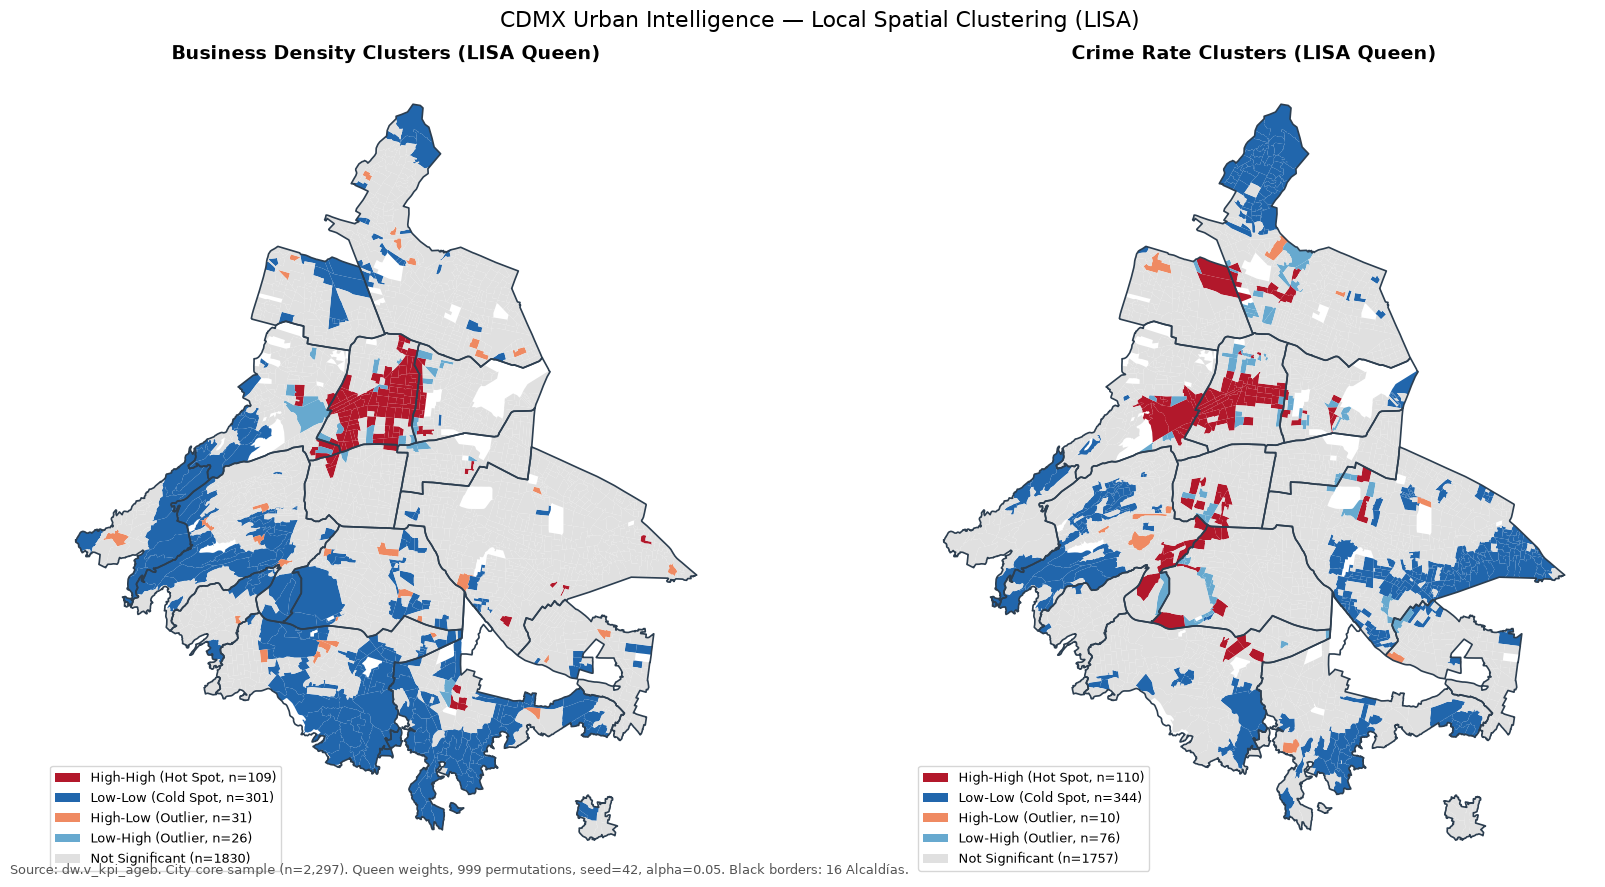

Saved cluster comparison map to /Users/joseangel/Developer/E2 Datawarehouse Design/merida-urban-intelligence/outputs/maps/34_hotspot_clusters_alcaldia.png


In [5]:
# Prepare spatial GeoDataFrame with clusters
map_gdf = gdf_rate.copy()
map_gdf['biz_cluster'] = lisa_biz_q.loc[gdf_rate.index, 'cluster']
map_gdf['crime_cluster'] = lisa_crime_q['cluster']

# Combine category for dual hotspot
def classify_dual(row):
    if row['biz_cluster'] == 'HH' and row['crime_cluster'] == 'HH':
        return 'Dual HH (Biz & Crime)'
    elif row['biz_cluster'] == 'HH':
        return 'Biz Density HH only'
    elif row['crime_cluster'] == 'HH':
        return 'Crime Rate HH only'
    elif row['biz_cluster'] == 'LL' and row['crime_cluster'] == 'LL':
        return 'Dual LL (Biz & Crime)'
    else:
        return 'Other / Not Significant'

map_gdf['dual_type'] = map_gdf.apply(classify_dual, axis=1)

# Dissolve alcaldia boundaries
alcaldias = gdf_core.dissolve(by='mun_name')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Panel 1: Business Density LISA vs Crime Rate LISA side-by-side
for ax, (col, title) in zip(axes, [
    ('biz_cluster', 'Business Density Clusters (LISA Queen)'),
    ('crime_cluster', 'Crime Rate Clusters (LISA Queen)')
]):
    for cat, color in LISA_COLORS.items():
        subset = map_gdf[map_gdf[col] == cat]
        if not subset.empty:
            subset.plot(ax=ax, color=color, edgecolor='none', linewidth=0)
    alcaldias.boundary.plot(ax=ax, color='#2c3e50', linewidth=1.2)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

    # Legend
    legend_elements = [
        Patch(facecolor=LISA_COLORS['HH'], label=f'High-High (Hot Spot, n={map_gdf[col].eq("HH").sum()})'),
        Patch(facecolor=LISA_COLORS['LL'], label=f'Low-Low (Cold Spot, n={map_gdf[col].eq("LL").sum()})'),
        Patch(facecolor=LISA_COLORS['HL'], label=f'High-Low (Outlier, n={map_gdf[col].eq("HL").sum()})'),
        Patch(facecolor=LISA_COLORS['LH'], label=f'Low-High (Outlier, n={map_gdf[col].eq("LH").sum()})'),
        Patch(facecolor=LISA_COLORS['ns'], label=f'Not Significant (n={map_gdf[col].eq("ns").sum()})')
    ]
    ax.legend(handles=legend_elements, loc='lower left', frameon=True, fontsize=9)

fig.suptitle("CDMX Urban Intelligence — Local Spatial Clustering (LISA)", fontsize=16, y=0.98)
fig.text(0.05, 0.02, "Source: dw.v_kpi_ageb. City core sample (n=2,297). Queen weights, 999 permutations, seed=42, alpha=0.05. Black borders: 16 Alcaldías.", fontsize=9, color='#555')
plt.tight_layout()

map_path = OUTPUT_MAPS / "34_hotspot_clusters_alcaldia.png"
fig.savefig(map_path, dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved cluster comparison map to {map_path}")

## 5. Robustness & Spatial Sensitivity Analysis

To verify that spatial clustering is not an artifact of the contiguity graph rule, we evaluate the stability of cluster classifications between **Queen contiguity** and **K-Nearest-Neighbors (k=6)**.

In [6]:
biz_stability = (overlap['biz_cluster'] == overlap['biz_cluster_knn']).mean()
crime_stability = (overlap['crime_cluster'] == overlap['crime_cluster_knn']).mean()

robustness_df = pd.DataFrame({
    'Indicator': ['Business Density (km²)', 'Crime Rate (per 1k pop)'],
    'Sample Size (n)': [len(overlap), len(overlap)],
    'Queen HH Count': [overlap['biz_cluster'].eq('HH').sum(), overlap['crime_cluster'].eq('HH').sum()],
    'KNN-6 HH Count': [overlap['biz_cluster_knn'].eq('HH').sum(), overlap['crime_cluster_knn'].eq('HH').sum()],
    'Label Stability (Queen vs KNN-6)': [f"{biz_stability:.1%}", f"{crime_stability:.1%}"]
})
display(robustness_df)

print(f"\nKey takeaway: Cluster labels exhibit high spatial stability (>87% agreement),")
print("confirming that observed hot spots reflect genuine territorial concentrations rather than edge effects.")

,Indicator,Sample Size (n),Queen HH Count,KNN-6 HH Count,Label Stability (Queen vs KNN-6)
0,Business Density (km²),2297,109,120,89.3%
1,Crime Rate (per 1k pop),2297,110,72,87.0%



Key takeaway: Cluster labels exhibit high spatial stability (>87% agreement),
confirming that observed hot spots reflect genuine territorial concentrations rather than edge effects.
